Device: cuda
Loading / training eye classifier...
Model already exists. Using default threshold: 0.5
Loaded best model.
Video: 640x360, 29.00 FPS, 1198 frames, 41.31s


Analyzing video:   0%|          | 0/1198 [00:00<?, ?it/s]

Left scores — min: 0.000 | mean: 0.012 | max: 0.218

BLINK COUNTS
Patient RIGHT eye: 31
Patient LEFT  eye: 7

RIGHT eye blink intervals:
  Blink 1: frame 18 -> 23   (0.62s to 0.79s)
  Blink 2: frame 37 -> 37   (1.28s to 1.28s)
  Blink 3: frame 82 -> 86   (2.83s to 2.97s)
  Blink 4: frame 132 -> 132   (4.55s to 4.55s)
  Blink 5: frame 164 -> 164   (5.66s to 5.66s)
  Blink 6: frame 217 -> 218   (7.48s to 7.52s)
  Blink 7: frame 262 -> 264   (9.03s to 9.10s)
  Blink 8: frame 317 -> 321   (10.93s to 11.07s)
  Blink 9: frame 370 -> 375   (12.76s to 12.93s)
  Blink 10: frame 428 -> 439   (14.76s to 15.14s)
  Blink 11: frame 471 -> 472   (16.24s to 16.28s)
  Blink 12: frame 497 -> 499   (17.14s to 17.21s)
  Blink 13: frame 519 -> 519   (17.90s to 17.90s)
  Blink 14: frame 549 -> 549   (18.93s to 18.93s)
  Blink 15: frame 641 -> 642   (22.10s to 22.14s)
  Blink 16: frame 662 -> 664   (22.83s to 22.90s)
  Blink 17: frame 705 -> 712   (24.31s to 24.55s)
  Blink 18: frame 726 -> 726   (25.03s to 

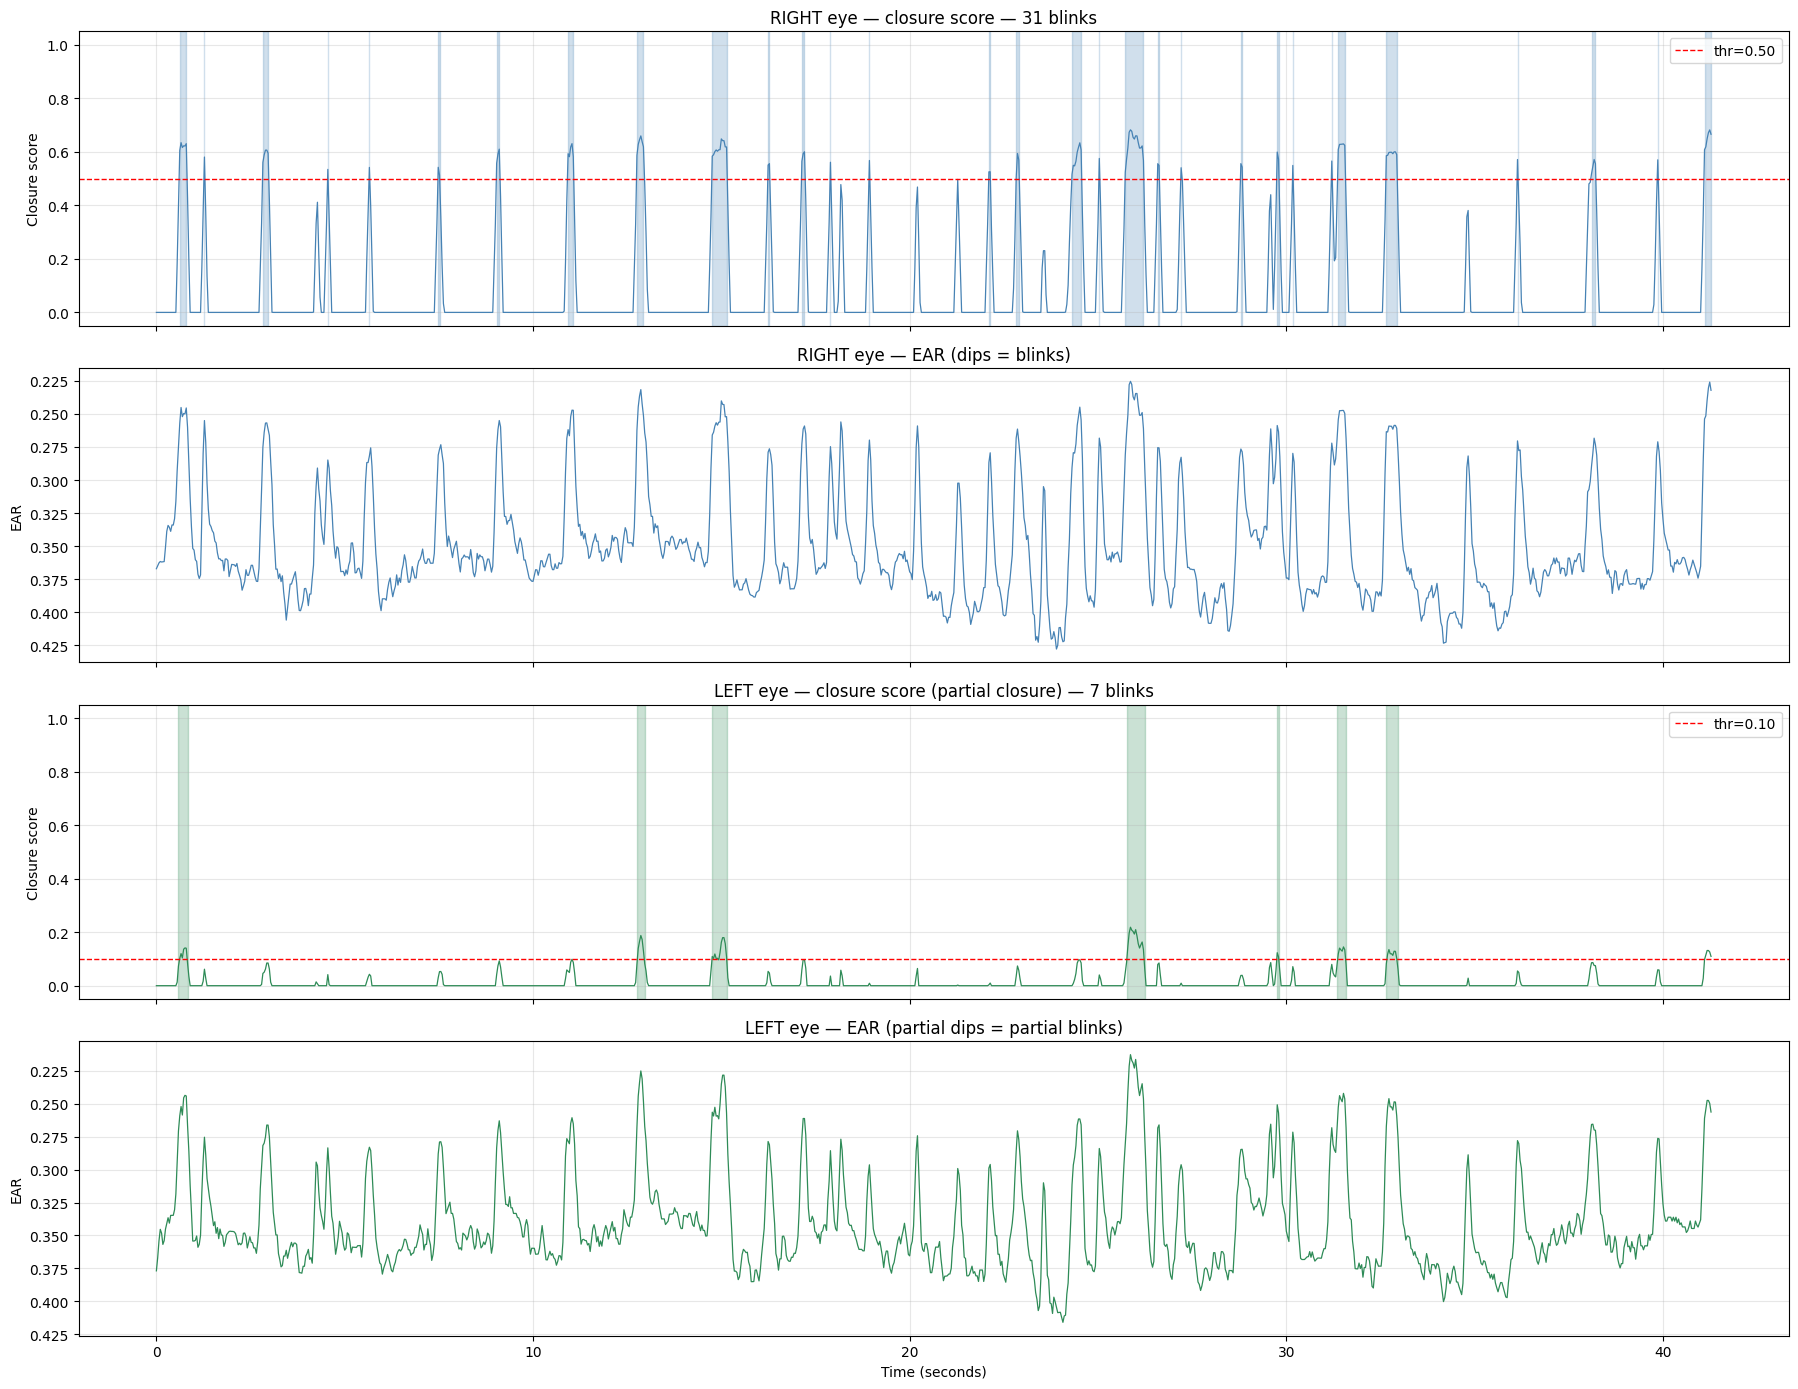

Saved plot to: /kaggle/working/blink_timeline.png
Saved: /kaggle/working/blink_counts.json


In [2]:

"""
Robust blink counter using:
1) a pre-trained facial landmark model (dlib 68-point predictor) to find/crop eyes
2) a CNN trained on the shared eye-state dataset to classify open vs closed
3) a temporal blink counter per eye

Update the paths in Config before running.
"""

import os
import math
import json
import random
import urllib.request
import bz2
from dataclasses import dataclass
from collections import defaultdict

import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T


# -----------------------------
# Config
# -----------------------------
@dataclass
class Config:
    DATASET_DIR: str = "/kaggle/input/datasets/kuldipkmanvar/blink-detection-dataset/Blink Detection Dataset"
    VIDEO_PATH: str = "/kaggle/input/datasets/kuldipkmanvar/patient-video/patient.mp4"
    OUTPUT_DIR: str = "/kaggle/working"
    MODEL_PATH: str = "/kaggle/working/eye_state_cnn_best.pth"
    PREDICTOR_PATH = "/kaggle/input/datasets/kuldipkmanvar/68-face-landmarks-detector/shape_predictor_68_face_landmarks.dat"

    IMG_SIZE: int = 64
    BATCH_SIZE: int = 128
    EPOCHS: int = 8
    LR: float = 1e-3
    WEIGHT_DECAY: float = 1e-4
    VAL_SPLIT: float = 0.15
    SEED: int = 42

    # blink logic
    # blink logic
    SMOOTH_WINDOW: int = 3          # reduced from 5 — preserves fast blinks better
    MAX_MISSING_FRAMES: int = 2
    MIN_CLOSED_FRAMES: int = 1

    # eye crop
    EYE_PAD_RATIO: float = 0.35
    EYE_PAD_PIXELS: int = 6

    # thresholds — separate per eye because left eye only partially closes
    DEFAULT_CLOSED_THRESHOLD: float = 0.5   # right eye (normal)
    LEFT_CLOSED_THRESHOLD: float = 0.10     # left eye (partial closure patient)

    # EAR settings
    EAR_OPEN: float = 0.30      # EAR at fully open (used for normalization)
    EAR_CLOSED: float = 0.10    # EAR at fully closed
    EAR_CNN_WEIGHT: float = 0.5 # weight for CNN score in fusion (EAR gets 1 - this)

    # peak detection for left eye (find_peaks params)
    LEFT_MIN_BLINK_DISTANCE: int = 10   # minimum frames between two left-eye blinks
    LEFT_MIN_PROMINENCE: float = 0.06   # minimum rise above surroundings to count

cfg = Config()

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)


# -----------------------------
# Reproducibility
# -----------------------------
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(cfg.SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# -----------------------------
# Utilities
# -----------------------------
def ensure_shape_predictor(output_dir: str) -> str:
    """
    Download dlib's 68-landmark predictor if missing.
    """
    predictor_path = os.path.join(output_dir, "shape_predictor_68_face_landmarks.dat")
    if os.path.exists(predictor_path):
        return predictor_path

    bz2_path = predictor_path + ".bz2"
    url = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"
    print("Downloading facial landmark model...")
    urllib.request.urlretrieve(url, bz2_path)
    with bz2.open(bz2_path, "rb") as fin, open(predictor_path, "wb") as fout:
        fout.write(fin.read())
    print("Downloaded:", predictor_path)
    return predictor_path


def parse_eye_dataset(root_dir: str):
    """
    Parse open/closed labels from folder names or file names.
    Returns list of (path, label) where label: 0=closed, 1=open
    """
    all_images = []
    for root, _, files in os.walk(root_dir):
        for f in files:
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                all_images.append(os.path.join(root, f))

    parsed = []
    for p in all_images:
        folder = os.path.basename(os.path.dirname(p)).lower()
        fname = os.path.splitext(os.path.basename(p))[0].lower()

        label = None
        if "closed" in folder or "closed" in fname:
            label = 0
        elif "open" in folder or "open" in fname:
            label = 1
        else:
            parts = fname.split("_")
            if len(parts) >= 5:
                try:
                    state = int(parts[4])
                    if state in (0, 1):
                        label = state
                except:
                    pass

        if label is not None:
            parsed.append((p, label))

    if not parsed:
        raise RuntimeError(f"No labeled images found in {root_dir}")

    closed = [x for x in parsed if x[1] == 0]
    open_ = [x for x in parsed if x[1] == 1]

    # balance by capping each class to avoid skew
    cap = min(len(closed), len(open_), 15000)
    random.shuffle(closed)
    random.shuffle(open_)
    balanced = closed[:cap] + open_[:cap]
    random.shuffle(balanced)
    return balanced


class EyeDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label = self.items[idx]
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((cfg.IMG_SIZE, cfg.IMG_SIZE), dtype=np.uint8)
        img = cv2.resize(img, (cfg.IMG_SIZE, cfg.IMG_SIZE), interpolation=cv2.INTER_AREA)
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        else:
            img = T.ToTensor()(img)
        return img, torch.tensor(label, dtype=torch.long)


train_tf = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5]),
])

val_tf = T.Compose([
    T.ToTensor(),
    T.Normalize([0.5], [0.5]),
])


def split_train_val(items, val_split=0.15):
    items = items[:]
    random.shuffle(items)
    n_val = int(len(items) * val_split)
    return items[n_val:], items[:n_val]


# -----------------------------
# Model
# -----------------------------
class EyeStateCNN(nn.Module):
    """
    Compact binary eye-state classifier.
    Input:  (B,1,64,64)
    Output: logits for [closed, open]
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.45),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(256, 2),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# -----------------------------
# Train / Eval
# -----------------------------
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_n = 0

    all_closed_probs = []
    all_labels = []

    for imgs, labels in tqdm(loader, leave=False):
        imgs = imgs.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

        logits = model(imgs)
        loss = criterion(logits, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        probs_closed = torch.softmax(logits, dim=1)[:, 0].detach().cpu().numpy()
        preds = logits.argmax(dim=1)

        total_loss += loss.item() * imgs.size(0)
        total_correct += (preds == labels).sum().item()
        total_n += labels.size(0)

        all_closed_probs.extend(probs_closed.tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    return {
        "loss": total_loss / max(total_n, 1),
        "acc": total_correct / max(total_n, 1),
        "closed_probs": np.array(all_closed_probs, dtype=np.float32),
        "labels": np.array(all_labels, dtype=np.int64),
    }


def best_threshold_from_probs(y_true, p_closed):
    """
    Choose threshold that maximizes F1 for the CLOSED class.
    y_true: 0=closed, 1=open  (dataset convention)
    p_closed: probability that the eye is closed
    """
    thresholds = np.linspace(0.05, 0.95, 181)
    best_t, best_f1 = 0.5, -1.0

    for t in thresholds:
        y_pred_closed = (p_closed >= t).astype(np.int64)   # 1 = predict closed
        true_closed   = (y_true == 0).astype(np.int64)     # 1 = actually closed

        tp = np.sum((y_pred_closed == 1) & (true_closed == 1))
        fp = np.sum((y_pred_closed == 1) & (true_closed == 0))
        fn = np.sum((y_pred_closed == 0) & (true_closed == 1))
        precision = tp / max(tp + fp, 1)
        recall    = tp / max(tp + fn, 1)
        f1 = 2 * precision * recall / max(precision + recall, 1e-12)
        if f1 > best_f1:
            best_f1 = f1
            best_t  = float(t)

    return best_t, best_f1


def train_classifier():
    items = parse_eye_dataset(cfg.DATASET_DIR)
    train_items, val_items = split_train_val(items, cfg.VAL_SPLIT)

    train_ds = EyeDataset(train_items, transform=train_tf)
    val_ds = EyeDataset(val_items, transform=val_tf)

    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=0)

    model = EyeStateCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    best_val_acc = -1.0
    best_threshold = cfg.DEFAULT_CLOSED_THRESHOLD
    history = []

    for epoch in range(cfg.EPOCHS):
        tr = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        va = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step()

        t, f1 = best_threshold_from_probs(va["labels"], va["closed_probs"])
        if va["acc"] > best_val_acc:
            best_val_acc = va["acc"]
            best_threshold = t
            torch.save(model.state_dict(), cfg.MODEL_PATH)

        history.append({
            "epoch": epoch + 1,
            "train_loss": tr["loss"],
            "train_acc": tr["acc"],
            "val_loss": va["loss"],
            "val_acc": va["acc"],
            "threshold": t,
            "val_f1_closed": f1,
        })

        print(f"Epoch {epoch+1}/{cfg.EPOCHS} | "
              f"train acc {tr['acc']:.4f} | val acc {va['acc']:.4f} | "
              f"best thr {t:.3f} | closed-F1 {f1:.4f}")

    with open(os.path.join(cfg.OUTPUT_DIR, "training_history.json"), "w") as f:
        json.dump(history, f, indent=2)

    print(f"Saved best model to: {cfg.MODEL_PATH}")
    print(f"Calibrated closed-eye threshold: {best_threshold:.3f}")
    return best_threshold


# -----------------------------
# Landmark-based eye cropping
# -----------------------------
def shape_to_np(shape):
    coords = np.zeros((68, 2), dtype=np.int32)
    for i in range(68):
        coords[i] = (shape.part(i).x, shape.part(i).y)
    return coords


def expand_bbox(x1, y1, x2, y2, pad_ratio, pad_px, W, H):
    w = x2 - x1
    h = y2 - y1
    pad_x = int(w * pad_ratio) + pad_px
    pad_y = int(h * pad_ratio) + pad_px
    x1 = max(0, x1 - pad_x)
    y1 = max(0, y1 - pad_y)
    x2 = min(W, x2 + pad_x)
    y2 = min(H, y2 + pad_y)
    return x1, y1, x2, y2


def crop_eye_from_landmarks(gray, pts, eye_side):
    """
    eye_side: 'right' or 'left' from the patient's perspective.
    dlib 68 landmarks:
        36-41 -> patient's right eye
        42-47 -> patient's left eye
    """
    if eye_side == "right":
        idx = list(range(36, 42))
    elif eye_side == "left":
        idx = list(range(42, 48))
    else:
        raise ValueError("eye_side must be 'right' or 'left'")

    eye_pts = pts[idx]
    x1, y1 = eye_pts.min(axis=0)
    x2, y2 = eye_pts.max(axis=0)

    H, W = gray.shape[:2]
    x1, y1, x2, y2 = expand_bbox(x1, y1, x2, y2, cfg.EYE_PAD_RATIO, cfg.EYE_PAD_PIXELS, W, H)

    if x2 <= x1 or y2 <= y1:
        return None, None

    crop = gray[y1:y2, x1:x2]
    if crop.size == 0:
        return None, None

    return crop, (x1, y1, x2, y2)


# -----------------------------
# EAR + fusion
# -----------------------------
def eye_aspect_ratio(pts, eye_side):
    """
    Compute EAR from dlib 68-point landmarks.
    Right eye: pts[36:42], Left eye: pts[42:48]
    EAR = (|p2-p6| + |p3-p5|) / (2 * |p1-p4|)
    """
    p = pts[36:42] if eye_side == "right" else pts[42:48]
    A = np.linalg.norm(p[1].astype(float) - p[5].astype(float))
    B = np.linalg.norm(p[2].astype(float) - p[4].astype(float))
    C = np.linalg.norm(p[0].astype(float) - p[3].astype(float))
    return float((A + B) / (2.0 * C)) if C > 0 else 0.0


def compute_closure_score(ear, cnn_prob_closed):
    """
    Fuse EAR and CNN into one closure score (0=open, 1=closed).
    EAR is inverted: lower EAR → higher closure.
    """
    ear_score = float(np.clip(
        (cfg.EAR_OPEN - ear) / (cfg.EAR_OPEN - cfg.EAR_CLOSED), 0.0, 1.0
    ))
    cnn_score = cnn_prob_closed if cnn_prob_closed is not None else ear_score
    return (1 - cfg.EAR_CNN_WEIGHT) * ear_score + cfg.EAR_CNN_WEIGHT * cnn_score


def calibrate_ear_threshold(ear_series, percentile=15):
    """
    Auto-set left-eye closure threshold from observed EAR distribution.
    Uses Nth percentile — adapts to this specific patient's range of motion.
    Only used if you want fully automatic calibration; otherwise LEFT_CLOSED_THRESHOLD is used.
    """
    valid = [e for e in ear_series if e is not None]
    if not valid:
        return 0.20
    # convert EAR percentile back to a closure score
    ear_at_pct = float(np.percentile(valid, percentile))
    return float(np.clip(
        (cfg.EAR_OPEN - ear_at_pct) / (cfg.EAR_OPEN - cfg.EAR_CLOSED), 0.0, 1.0
    ))


def count_blinks_peaks(scores, threshold, min_distance, min_prominence):
    """
    Detect blinks as peaks in the closure score signal.
    Better than binary transitions for partial/incomplete blinks.
    scores: list of floats (None treated as 0)
    """
    from scipy.signal import find_peaks
    arr = np.array([s if s is not None else 0.0 for s in scores])
    peaks, _ = find_peaks(
        arr,
        height=threshold,
        distance=min_distance,
        prominence=min_prominence,
    )
    intervals = []
    for pk in peaks:
        # expand each peak to find the full blink window
        start, end = int(pk), int(pk)
        half_thr = threshold * 0.6
        while start > 0 and arr[start - 1] >= half_thr:
            start -= 1
        while end < len(arr) - 1 and arr[end + 1] >= half_thr:
            end += 1
        intervals.append((start, end))
    return int(len(peaks)), intervals

def preprocess_crop(crop):
    crop = cv2.resize(crop, (cfg.IMG_SIZE, cfg.IMG_SIZE), interpolation=cv2.INTER_AREA)
    crop = Image.fromarray(crop)
    tensor = T.Compose([
        T.ToTensor(),
        T.Normalize([0.5], [0.5]),
    ])(crop)
    return tensor.unsqueeze(0)


@torch.no_grad()
def classify_crop(model, crop, closed_threshold):
    """
    Returns:
      closed_prob, state
      state: 1=closed, 0=open
    """
    if crop is None or crop.size == 0:
        return None, None

    x = preprocess_crop(crop).to(device)
    logits = model(x)
    prob_closed = torch.softmax(logits, dim=1)[0, 0].item()
    state = 1 if prob_closed >= closed_threshold else 0
    return prob_closed, state


def smooth_series(values, window=5):
    """
    Smooth numeric series while ignoring None.
    Returns a list of same length.
    """
    out = []
    half = window // 2
    for i in range(len(values)):
        s = max(0, i - half)
        e = min(len(values), i + half + 1)
        chunk = [v for v in values[s:e] if v is not None]
        out.append(float(np.mean(chunk)) if chunk else None)
    return out


def fill_short_gaps(states, max_gap=2):
    """
    Fill short None gaps using surrounding states.
    states: list of 0(open), 1(closed), None
    """
    out = states[:]
    n = len(out)
    i = 0
    while i < n:
        if out[i] is not None:
            i += 1
            continue

        j = i
        while j < n and out[j] is None:
            j += 1
        gap_len = j - i

        left = out[i - 1] if i - 1 >= 0 else None
        right = out[j] if j < n else None

        if gap_len <= max_gap:
            if left is not None and right is not None:
                if left == right:
                    for k in range(i, j):
                        out[k] = left
                else:
                    # if they disagree, prefer the more recent state
                    for k in range(i, j):
                        out[k] = left
            elif left is not None:
                for k in range(i, j):
                    out[k] = left
            elif right is not None:
                for k in range(i, j):
                    out[k] = right

        i = j
    return out


def count_blinks(states, min_closed_frames=1):
    """
    Count open->closed->open transitions on a binary sequence.
    states: 0=open, 1=closed (no None after gap filling)
    """
    blinks = 0
    intervals = []
    i = 0
    n = len(states)
    while i < n:
        if states[i] == 1:
            start = i
            while i < n and states[i] == 1:
                i += 1
            end = i - 1
            run_len = end - start + 1
            if run_len >= min_closed_frames:
                blinks += 1
                intervals.append((start, end))
        else:
            i += 1
    return blinks, intervals


# -----------------------------
# Video inference
# -----------------------------
def analyze_video(model, video_path, right_threshold, left_threshold):
    detector  = dlib.get_frontal_face_detector()
    predictor = dlib.shape_predictor(cfg.PREDICTOR_PATH)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {video_path}")

    fps          = cap.get(cv2.CAP_PROP_FPS) or 30.0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration     = total_frames / fps if fps > 0 else 0

    print(f"Video: {width}x{height}, {fps:.2f} FPS, {total_frames} frames, {duration:.2f}s")

    right_probs, left_probs         = [], []
    right_ear_raw, left_ear_raw     = [], []
    right_states_raw, left_states_raw = [], []
    frame_times                     = []
    crops_for_debug                 = []

    last_rect = None
    face_miss = 0

    pbar      = tqdm(total=total_frames, desc="Analyzing video")
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        rects = detector(gray, 0)

        if len(rects) > 0:
            rect      = max(rects, key=lambda r: r.width() * r.height())
            last_rect = rect
            face_miss = 0
        else:
            face_miss += 1
            rect = last_rect if (last_rect is not None and face_miss <= 2) else None

        if rect is None:
            right_probs.append(None);  left_probs.append(None)
            right_ear_raw.append(None); left_ear_raw.append(None)
            right_states_raw.append(None); left_states_raw.append(None)
            frame_times.append(frame_idx / fps)
            frame_idx += 1; pbar.update(1)
            continue

        shape = predictor(gray, rect)
        pts   = shape_to_np(shape)

        # --- EAR (geometric signal) ---
        r_ear = eye_aspect_ratio(pts, "right")
        l_ear = eye_aspect_ratio(pts, "left")
        right_ear_raw.append(r_ear)
        left_ear_raw.append(l_ear)

        # --- CNN probability ---
        right_crop, _ = crop_eye_from_landmarks(gray, pts, "right")
        left_crop,  _ = crop_eye_from_landmarks(gray, pts, "left")

        # flip left crop horizontally so CNN sees it like a right eye
        if left_crop is not None:
            left_crop = cv2.flip(left_crop, 1)

        rp, rs = classify_crop(model, right_crop, right_threshold)
        lp, ls = classify_crop(model, left_crop,  left_threshold)

        right_probs.append(rp)
        left_probs.append(lp)
        right_states_raw.append(rs)
        left_states_raw.append(ls)
        frame_times.append(frame_idx / fps)

        if len(crops_for_debug) < 24 and frame_idx % max(1, int(fps)) == 0:
            crops_for_debug.append((frame_idx, right_crop, left_crop, rp, lp, rs, ls))

        frame_idx += 1
        pbar.update(1)

    pbar.close()
    cap.release()

    # --- Smooth raw signals ---
    right_probs_s = smooth_series(right_probs, window=cfg.SMOOTH_WINDOW)
    left_probs_s  = smooth_series(left_probs,  window=cfg.SMOOTH_WINDOW)
    right_ear_s   = smooth_series(right_ear_raw, window=cfg.SMOOTH_WINDOW)
    left_ear_s    = smooth_series(left_ear_raw,  window=cfg.SMOOTH_WINDOW)

    # --- Fuse EAR + CNN into closure scores ---
    right_scores = [
        None if (rp is None and re is None)
        else compute_closure_score(re if re is not None else cfg.EAR_OPEN, rp or 0.0)
        for rp, re in zip(right_probs_s, right_ear_s)
    ]
    left_scores = [
        None if (lp is None and le is None)
        else compute_closure_score(le if le is not None else cfg.EAR_OPEN, lp or 0.0)
        for lp, le in zip(left_probs_s, left_ear_s)
    ]

    # --- Right eye: binary threshold (normal eye, clean blinks) ---
    right_states = [
        None if s is None else (1 if s >= right_threshold else 0)
        for s in right_scores
    ]
    right_states = fill_short_gaps(right_states, max_gap=cfg.MAX_MISSING_FRAMES)
    right_blinks, right_intervals = count_blinks(right_states, cfg.MIN_CLOSED_FRAMES)

    # --- Left eye: peak detection (partial closure patient) ---
    left_blinks, left_intervals = count_blinks_peaks(
        left_scores,
        threshold      = left_threshold,
        min_distance   = cfg.LEFT_MIN_BLINK_DISTANCE,
        min_prominence = cfg.LEFT_MIN_PROMINENCE,
    )

    return {
        "fps":             fps,
        "frame_times":     frame_times,
        "right_probs":     right_probs_s,
        "left_probs":      left_probs_s,
        "right_ear":       right_ear_s,
        "left_ear":        left_ear_s,
        "right_scores":    right_scores,
        "left_scores":     left_scores,
        "right_states":    right_states,
        "right_blinks":    right_blinks,
        "left_blinks":     left_blinks,
        "right_intervals": right_intervals,
        "left_intervals":  left_intervals,
        "debug_crops":     crops_for_debug,
        "duration":        duration,
        "total_frames":    total_frames,
    }

def plot_results(res, right_threshold, left_threshold):
    times = res["frame_times"]
    fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True)

    # Right eye closure score
    axes[0].plot(times, [np.nan if s is None else s for s in res["right_scores"]], lw=0.9, color="steelblue")
    axes[0].axhline(right_threshold, ls="--", color="red", lw=1, label=f"thr={right_threshold:.2f}")
    for s, e in res["right_intervals"]:
        axes[0].axvspan(times[s], times[e], alpha=0.25, color="steelblue")
    axes[0].set_ylabel("Closure score")
    axes[0].set_title(f"RIGHT eye — closure score — {res['right_blinks']} blinks")
    axes[0].set_ylim(-0.05, 1.05)
    axes[0].legend(loc="upper right"); axes[0].grid(alpha=0.3)

    # Right EAR (inverted axis: low EAR = more closed)
    axes[1].plot(times, [np.nan if e is None else e for e in res["right_ear"]], lw=0.9, color="steelblue")
    axes[1].set_ylabel("EAR")
    axes[1].set_title("RIGHT eye — EAR (dips = blinks)")
    axes[1].invert_yaxis()
    axes[1].grid(alpha=0.3)

    # Left eye closure score
    axes[2].plot(times, [np.nan if s is None else s for s in res["left_scores"]], lw=0.9, color="seagreen")
    axes[2].axhline(left_threshold, ls="--", color="red", lw=1, label=f"thr={left_threshold:.2f}")
    for s, e in res["left_intervals"]:
        axes[2].axvspan(times[s], times[e], alpha=0.25, color="seagreen")
    axes[2].set_ylabel("Closure score")
    axes[2].set_title(f"LEFT eye — closure score (partial closure) — {res['left_blinks']} blinks")
    axes[2].set_ylim(-0.05, 1.05)
    axes[2].legend(loc="upper right"); axes[2].grid(alpha=0.3)

    # Left EAR — key diagnostic plot: shows partial dips the CNN misses
    axes[3].plot(times, [np.nan if e is None else e for e in res["left_ear"]], lw=0.9, color="seagreen")
    axes[3].set_ylabel("EAR")
    axes[3].set_title("LEFT eye — EAR (partial dips = partial blinks)")
    axes[3].invert_yaxis()
    axes[3].set_xlabel("Time (seconds)")
    axes[3].grid(alpha=0.3)

    plt.tight_layout()
    out = os.path.join(cfg.OUTPUT_DIR, "blink_timeline.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved plot to:", out)


def print_summary(res):
    print("\n" + "=" * 72)
    print("BLINK COUNTS")
    print("=" * 72)
    print(f"Patient RIGHT eye: {res['right_blinks']}")
    print(f"Patient LEFT  eye: {res['left_blinks']}")

    print("\nRIGHT eye blink intervals:")
    for i, (s, e) in enumerate(res["right_intervals"], 1):
        print(f"  Blink {i}: frame {s} -> {e}   ({res['frame_times'][s]:.2f}s to {res['frame_times'][e]:.2f}s)")

    print("\nLEFT eye blink intervals:")
    for i, (s, e) in enumerate(res["left_intervals"], 1):
        print(f"  Blink {i}: frame {s} -> {e}   ({res['frame_times'][s]:.2f}s to {res['frame_times'][e]:.2f}s)")

    # EAR diagnostics for the partial-closure eye
    left_ear_valid = [e for e in res["left_ear"] if e is not None]
    if left_ear_valid:
        print(f"\n  Left EAR stats — min: {min(left_ear_valid):.3f} | "
              f"mean: {np.mean(left_ear_valid):.3f} | "
              f"max: {max(left_ear_valid):.3f}")
        print(f"  (Lower min = deeper closure reached during video)")
# -----------------------------
# Main
# -----------------------------
def main():
    print("Loading / training eye classifier...")
    if not os.path.exists(cfg.MODEL_PATH):
        threshold = train_classifier()
    else:
        # still train/calc threshold if you want, otherwise use default
        threshold = cfg.DEFAULT_CLOSED_THRESHOLD
        print("Model already exists. Using default threshold:", threshold)

    model = EyeStateCNN().to(device)
    model.load_state_dict(torch.load(cfg.MODEL_PATH, map_location=device))
    model.eval()
    print("Loaded best model.")

    right_threshold = threshold                    # calibrated from training
    left_threshold  = cfg.LEFT_CLOSED_THRESHOLD    # lower — partial closure patient
    results = analyze_video(model, cfg.VIDEO_PATH, right_threshold, left_threshold)
    # add temporarily after analyze_video returns, in main():
    valid = [s for s in results["left_scores"] if s is not None]
    print(f"Left scores — min: {min(valid):.3f} | mean: {np.mean(valid):.3f} | max: {max(valid):.3f}")
    print_summary(results)
    plot_results(results, right_threshold, left_threshold)

    # save counts
    counts = {
        "right_eye_blinks":    results["right_blinks"],
        "left_eye_blinks":     results["left_blinks"],
        "right_threshold":     right_threshold,
        "left_threshold":      left_threshold,
        "fps":                 results["fps"],
        "frames":              results["total_frames"],
        "duration_sec":        results["duration"],
    }
    out_json = os.path.join(cfg.OUTPUT_DIR, "blink_counts.json")
    with open(out_json, "w") as f:
        json.dump(counts, f, indent=2)
    print("Saved:", out_json)


if __name__ == "__main__":
    main()